In [1]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path
# Notebooks run from the notebooks folder, so the src folder is added to the path.
sys.path.insert(0, str(Path.cwd().parent / "src"))
import numpy as np, rasterio, matplotlib.pyplot as plt
from tqdm import tqdm
import config

In [2]:
import joblib
from sklearn.ensemble import RandomForestClassifier
from prepare import load_chips
from metrics import split_chips, score
from features import build_table, FEATURE_NAMES

train, val, test = split_chips(load_chips())
X_train, y_train = build_table(train)
# A random sample of 2 million pixels is used to reduce training time.
sample = np.random.default_rng(42).choice(len(X_train), size=min(2_000_000, len(X_train)), replace=False)
X_train, y_train = X_train[sample], y_train[sample]
X_val, y_val = build_table(val)
X_test, y_test = build_table(test)

Tiles: 1127 train, 392 validation, 392 test


In [3]:
# Depth and leaf size limits prevent the trees from memorizing individual pixels.
settings = dict(n_estimators=200, max_depth=20, min_samples_leaf=5, n_jobs=-1, random_state=42)
# The first five columns are spectral; the last two are texture.
columns = {"color only": slice(0, 5), "color and texture": slice(None)}
models = {name: RandomForestClassifier(**settings).fit(X_train[:, cols], y_train) for name, cols in columns.items()}

In [4]:
# The decision to keep texture is made on the validation tiles.
for name, model in models.items():
    print(f"{name:18s} validation IoU {score(model.predict(X_val[:, columns[name]]), y_val)['iou']:.3f}")

color only         validation IoU 0.547
color and texture  validation IoU 0.578


In [5]:
# Both versions are scored on the same test tiles as the NDVI baseline.
for name, model in models.items():
    scores = score(model.predict(X_test[:, columns[name]]), y_test)
    print(f"{name:18s}", {k: round(v, 3) for k, v in scores.items()})

color only         {'iou': np.float64(0.488), 'precision': np.float64(0.649), 'recall': np.float64(0.663), 'f1': np.float64(0.656)}
color and texture  {'iou': np.float64(0.509), 'precision': np.float64(0.654), 'recall': np.float64(0.697), 'f1': np.float64(0.675)}


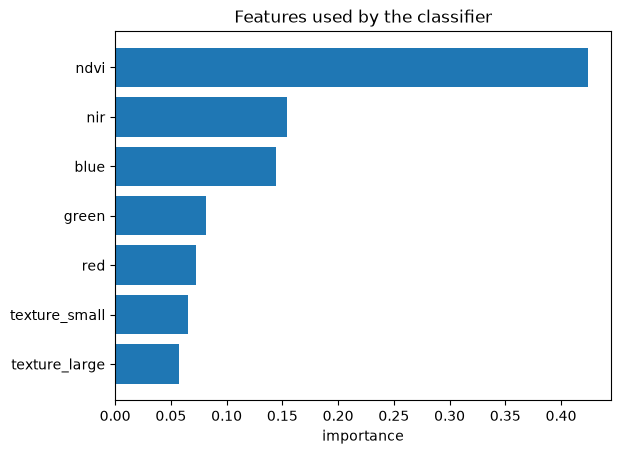

['C:\\Users\\Jamie\\Developer\\canopy-remote-sensing\\canopy_model.joblib']

In [6]:
final = models["color and texture"]
order = np.argsort(final.feature_importances_)
plt.barh(np.array(FEATURE_NAMES)[order], final.feature_importances_[order])
plt.xlabel("importance"); plt.title("Features used by the classifier")
plt.savefig(config.FIGURES / "03_feature_importance.png", dpi=120, bbox_inches="tight"); plt.show()
joblib.dump(final, config.MODEL_FILE)